# Beyond Image Classification

First inspect one pixel-wise update. Then train a foreground segmentation CNN using disjoint rectangle/ellipse layouts, select the best validation checkpoint, compare held-out IoU and Dice against a background baseline, and inspect test masks.

In [1]:
import torch
from torch import nn

torch.manual_seed(36)
torch.set_num_threads(1)
print('CPU | synthetic pixel segmentation')

CPU | synthetic pixel segmentation


In [2]:
def rectangles(count):
    images = torch.zeros(count, 1, 16, 16)
    masks = torch.zeros_like(images)
    for index in range(count):
        top = 2 + index % 6
        left = 2 + (index * 3) % 6
        height = 4 + index % 4
        width = 4 + (index + 1) % 4
        masks[index, 0, top:top+height, left:left+width] = 1
        images[index] = masks[index] + 0.05 * torch.randn(1, 16, 16)
    return images, masks

images, masks = rectangles(64)
print('images/masks:', tuple(images.shape), tuple(masks.shape))

images/masks: (64, 1, 16, 16) (64, 1, 16, 16)


In [3]:
model = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
                      nn.Conv2d(8, 8, 3, padding=1), nn.ReLU(), nn.Conv2d(8, 1, 1))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
logits = model(images)
loss = nn.functional.binary_cross_entropy_with_logits(logits, masks)
optimizer.zero_grad()
loss.backward()
optimizer.step()
with torch.no_grad():
    predicted = model(images) > 0
    intersection = (predicted & masks.bool()).sum().item()
    union = (predicted | masks.bool()).sum().item()
    iou = intersection / union
assert logits.shape == masks.shape and torch.isfinite(loss)
print(f'pixel loss={loss.item():.4f} | training IoU after one update={iou:.3f}')

pixel loss=0.6746 | training IoU after one update=0.691


## Complete project: held-out foreground segmentation

The earlier cell demonstrates one update. We now train a new model on separate synthetic scenes, select a checkpoint with validation BCE, and evaluate it once on test scenes. Each scene contains a rectangle or an ellipse, with random contrast, background texture, and observation noise. We split unique `(shape, top, left, height, width)` layouts before generating images: the same geometric template cannot occur in both training and test.

This remains a controlled segmentation task. It tests new layouts from the same generator, not real-world object recognition. A background-only baseline can obtain good pixel accuracy while missing every object, so we report foreground IoU and Dice as well.

In [4]:
import itertools, copy
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.manual_seed(360)
layout_candidates = list(itertools.product(['rectangle', 'ellipse'], range(1, 12, 2),
                                          range(1, 12, 2), [4, 6, 8], [4, 6, 8]))
layout_rng = torch.Generator().manual_seed(360)
layout_order = torch.randperm(len(layout_candidates), generator=layout_rng).tolist()
assert len(layout_candidates) >= 480
selected_layouts = [layout_candidates[i] for i in layout_order[:480]]
train_layouts, valid_layouts, test_layouts = selected_layouts[:320], selected_layouts[320:400], selected_layouts[400:]
assert not (set(train_layouts) & set(valid_layouts) or set(train_layouts) & set(test_layouts)
            or set(valid_layouts) & set(test_layouts))

def make_scenes(layouts, seed):
    generator = torch.Generator().manual_seed(seed)
    yy, xx = torch.meshgrid(torch.arange(20), torch.arange(20), indexing='ij')
    scene_images, scene_masks = [], []
    for shape, top, left, height, width in layouts:
        if shape == 'rectangle':
            mask = (yy >= top) & (yy < top + height) & (xx >= left) & (xx < left + width)
        else:
            mask = (((yy - (top + (height - 1) / 2)) / (height / 2)) ** 2
                    + ((xx - (left + (width - 1) / 2)) / (width / 2)) ** 2 <= 1)
        background = 0.15 + 0.15 * torch.rand((), generator=generator)
        contrast = 0.4 + 0.3 * torch.rand((), generator=generator)
        texture = 0.05 * torch.sin(xx.float() / 2 + torch.rand((), generator=generator) * 6)
        image = background + contrast * mask.float() + texture + 0.10 * torch.randn(20, 20, generator=generator)
        scene_images.append(image.unsqueeze(0))
        scene_masks.append(mask.float().unsqueeze(0))
    return torch.stack(scene_images), torch.stack(scene_masks)

seg_train_x, seg_train_y = make_scenes(train_layouts, 361)
seg_valid_x, seg_valid_y = make_scenes(valid_layouts, 362)
seg_test_x, seg_test_y = make_scenes(test_layouts, 363)
assert seg_train_x.shape == seg_train_y.shape == (320, 1, 20, 20)
assert set(seg_train_y.unique().tolist()) == {0.0, 1.0}
print('scene counts:', len(seg_train_x), len(seg_valid_x), len(seg_test_x))
assert (len(train_layouts), len(valid_layouts), len(test_layouts)) == (320, 80, 80)

scene counts: 320 80 80


### Preserve the grid and select without touching test labels

Three padded 3×3 convolution layers build local features. A 1×1 head gives one foreground logit per pixel, preserving 20×20 resolution. BCE receives logits and matching float targets. Mini-batches are shuffled with a seeded generator; validation performs no updates. We use a fixed probability threshold of 0.5, not one selected from test masks.

In [5]:
segmenter = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
                         nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
                         nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(), nn.Conv2d(8, 1, 1))
seg_optimizer = torch.optim.Adam(segmenter.parameters(), lr=0.003)
seg_history = []
best_seg_loss, best_seg_epoch, best_seg_state = float('inf'), None, None
batch_rng = torch.Generator().manual_seed(364)
for epoch in range(1, 41):
    segmenter.train()
    permutation = torch.randperm(len(seg_train_x), generator=batch_rng)
    total_train_loss = 0.0
    for indices in permutation.split(32):
        output = segmenter(seg_train_x[indices])
        loss = F.binary_cross_entropy_with_logits(output, seg_train_y[indices])
        seg_optimizer.zero_grad()
        loss.backward()
        seg_optimizer.step()
        total_train_loss += loss.item() * len(indices)
    segmenter.eval()
    with torch.no_grad():
        validation_loss = F.binary_cross_entropy_with_logits(segmenter(seg_valid_x), seg_valid_y).item()
    seg_history.append((total_train_loss / len(seg_train_x), validation_loss))
    if validation_loss < best_seg_loss:
        best_seg_loss, best_seg_epoch = validation_loss, epoch
        best_seg_state = copy.deepcopy(segmenter.state_dict())
assert best_seg_state is not None and torch.isfinite(torch.tensor(seg_history)).all()
segmenter.load_state_dict(best_seg_state)
segmenter.eval()
print('selected epoch:', best_seg_epoch, '| validation BCE:', round(best_seg_loss, 4))

selected epoch: 40 | validation BCE: 0.0087


In [6]:
@torch.no_grad()
def segmentation_metrics(prediction, target):
    prediction, truth = prediction.bool(), target.bool()
    assert prediction.shape == truth.shape
    axes = (1, 2, 3)
    intersection = (prediction & truth).sum(axes).float()
    union = (prediction | truth).sum(axes).float()
    denominator = prediction.sum(axes) + truth.sum(axes)
    # Explicit empty/empty convention: perfect overlap. Current scenes all contain foreground.
    image_iou = torch.where(union > 0, intersection / union.clamp_min(1), torch.ones_like(union))
    image_dice = torch.where(denominator > 0, 2 * intersection / denominator.clamp_min(1),
                             torch.ones_like(intersection))
    return {'pixel_accuracy': (prediction == truth).float().mean().item(),
            'global_iou': (intersection.sum() / union.sum().clamp_min(1)).item(),
            'mean_image_iou': image_iou.mean().item(), 'mean_image_dice': image_dice.mean().item()}

with torch.no_grad():
    seg_test_logits = segmenter(seg_test_x)
    seg_test_loss = F.binary_cross_entropy_with_logits(seg_test_logits, seg_test_y).item()
seg_test_prediction = seg_test_logits > 0
seg_metrics = segmentation_metrics(seg_test_prediction, seg_test_y)
background_metrics = segmentation_metrics(torch.zeros_like(seg_test_prediction), seg_test_y)
assert all(0 <= value <= 1 for value in seg_metrics.values())
assert background_metrics['global_iou'] == background_metrics['mean_image_dice'] == 0
# Independent metric sanity check: 1 TP, 1 FP, 1 FN gives IoU 1/3 and Dice 1/2.
metric_probe = segmentation_metrics(torch.tensor([[[[1, 1, 0]]]]), torch.tensor([[[[1, 0, 1]]]]))
assert abs(metric_probe['global_iou'] - 1 / 3) < 1e-6
assert abs(metric_probe['mean_image_dice'] - 0.5) < 1e-6
print('Test BCE:', round(seg_test_loss, 4))
for label, values in [('Selected CNN', seg_metrics), ('Background only', background_metrics)]:
    print(label, {key: round(value, 4) for key, value in values.items()})

Test BCE: 0.0056
Selected CNN {'pixel_accuracy': 0.9981, 'global_iou': 0.9784, 'mean_image_iou': 0.9764, 'mean_image_dice': 0.9877}
Background only {'pixel_accuracy': 0.9128, 'global_iou': 0.0, 'mean_image_iou': 0.0, 'mean_image_dice': 0.0}


### Inspect held-out masks and training behavior

Global IoU pools all intersections/unions; mean image IoU weights each image equally. They can differ when object sizes vary. Dice uses twice the intersection divided by the total predicted and true foreground. None of these metrics proves performance on photographs.

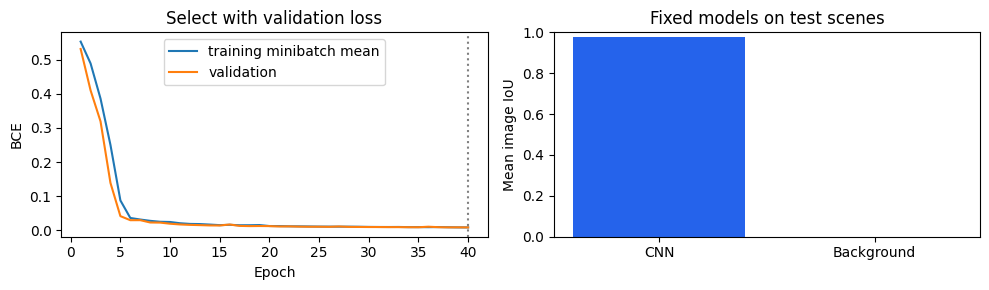

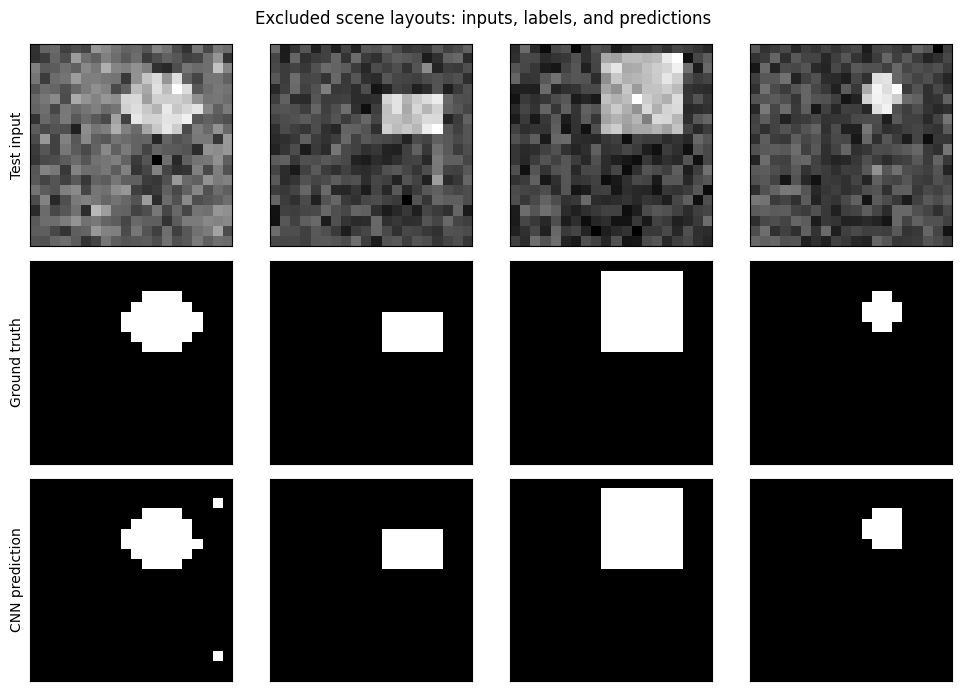

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(range(1, 41), [r[0] for r in seg_history], label='training minibatch mean')
axes[0].plot(range(1, 41), [r[1] for r in seg_history], label='validation')
axes[0].axvline(best_seg_epoch, color='gray', linestyle=':')
axes[0].set(xlabel='Epoch', ylabel='BCE', title='Select with validation loss'); axes[0].legend()
axes[1].bar(['CNN', 'Background'], [seg_metrics['mean_image_iou'], background_metrics['mean_image_iou']],
            color=['#2563EB', '#94A3B8'])
axes[1].set(ylim=(0, 1), ylabel='Mean image IoU', title='Fixed models on test scenes')
fig.tight_layout(); plt.show()
fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for column in range(4):
    axes[0, column].imshow(seg_test_x[column, 0], cmap='gray')
    axes[1, column].imshow(seg_test_y[column, 0], cmap='gray', vmin=0, vmax=1)
    axes[2, column].imshow(seg_test_prediction[column, 0], cmap='gray', vmin=0, vmax=1)
    for row in range(3):
        axes[row, column].set_xticks([]); axes[row, column].set_yticks([])
for row, title in enumerate(['Test input', 'Ground truth', 'CNN prediction']):
    axes[row, 0].set_ylabel(title)
fig.suptitle('Excluded scene layouts: inputs, labels, and predictions')
fig.tight_layout(); plt.show()

The complete project separates templates before image generation, performs 400 mini-batch updates, restores the validation-selected checkpoint, and compares a fixed CNN with a background baseline on 80 excluded layouts. Test plots describe the finished experiment; they are not used to retune it. More realistic segmentation would require richer images, labels, and a split matching the intended deployment setting.
